# Gestión y transformación de datos

En el presente Notebook se busca desarrollar el proceso de *ETL* (Extract, Transform and Load) el cual es un proceso fundamental en ingeniería de datos que combina información de múltiples fuentes de un almacén de datos centralizado (Data Warehouse).

Este proceso permite limpiar, organizar y estandarizar datos para mejorar el análisis y la toma de decisiones empresariales, siendo la base de la inteligencia empresarial.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## Importación de la base de datos

In [72]:
# Definimos la URL del repositorio en GitHub desde el cual se van a leer los datos.
url = 'https://raw.githubusercontent.com/Jero2110/Big_Data_Phase03/refs/heads/main/analisis/data/Anexo%201%20-%20Dataset1.csv'

try:
    # Intentamos leer el archivo con la URL entregada
    #  Para este caso, se determina un encoding 'latin1' con el fin de evitar inconvenientes
    #  con posibles caracteres no disponibles en UTF-8 que generen inconvenientes para cargar los datos
    df = pd.read_csv(url, encoding='latin1')
    
    # Verificamos que se haya leído correctamente
    print("---"*30)
    print("Archivo cargado con éxito")
    print("---"*30)
    print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
    
    # Mostramos una vista previa de los datos
    display(df.head()) 

except Exception as e:
    # En caso de presentarse cualquier error, el programa se detiene y se dan detalles del error generado
    print("---"*30)
    print("Error al cargar el archivo.")
    print("---"*30)
    print(f"Detalle técnico:\n{e}")


------------------------------------------------------------------------------------------
Archivo cargado con éxito
------------------------------------------------------------------------------------------
Dimensiones: 541909 filas y 8 columnas.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
## Contextualización de los datos

In [73]:
# Con el fin de conocer los tipos de datos disponibles en los registros cargados, ejecutamos el siguiente código
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [74]:
# Para mejorar la comprensión de los datos, se traducen los encabezados de las columnas del inglés al español 
#  Sin embargo, esto se realiza teniendo en cuenta que se trata de un ejercicio práctico, ya que al realizar esto
#  se puede llegar a generar una pérdida en la conexión de las posibles claves foráneas que existan en la base de datos
#  extraída. Lo cual implica que esta revisión quedaría desconcetada para la automatización y réplica de la información
df = df.rename(columns={'InvoiceNo': 'Nro_Factura',
                        'StockCode': 'Cod_Inventario',
                        'Description': 'Descripción',
                        'Quantity': 'Cantidad',
                        'InvoiceDate': 'Fecha_factura',
                        'UnitPrice': 'Precio_Unitario',
                        'CustomerID': 'ID_Cliente',
                        'Country': 'País'})

# Verificamos que se hayan cambiado los nombres de las columnas
print(f'Los nombres de las columnas son:\n{df.columns}')


Los nombres de las columnas son:
Index(['Nro_Factura', 'Cod_Inventario', 'Descripción', 'Cantidad',
       'Fecha_factura', 'Precio_Unitario', 'ID_Cliente', 'País'],
      dtype='str')


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Nro_Factura      541909 non-null  str    
 1   Cod_Inventario   541909 non-null  str    
 2   Descripción      540455 non-null  str    
 3   Cantidad         541909 non-null  int64  
 4   Fecha_factura    541909 non-null  str    
 5   Precio_Unitario  541909 non-null  float64
 6   ID_Cliente       406829 non-null  float64
 7   País             541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


---
## Transformación de datos

Teniendo en cuenta los tipos de datos almacenados en cada campo, se realizarán las transformaciones necesarias para preparar los datos para futuros análisis. Inicialmente, se dejará la columna número de factura en formato texto debido a que este campo puede contener números en la mayor parte de la información, pero puede contener letras dentro del número asignado. Por otra parte, debido a que el código de inventario (Cod_Inventario) puede contener texto, como se observa en las primeras líneas del DataFrame, se dejará como tipo texto; así mismo con la descripción y el país.

Por otra parte, la cantidad se dejará en formato entero, teniendo en cuenta que se puede tratar de productos enteros y no medidos o pesados donde se puede requerir de decimales. Por otra parte, el precio unitario se dejará en el tipo de dato flotante teniendo en cuenta que puede contener decimales importantes que no se pueden retirar en este punto del análisis.

Finalmente, se convertirá la fecha en tipo DateTime con el fin de facilitar futuros análisis que requieran de la agrupación de la información por fechas de ventas. Por otro lado, se convertirá el identificador del cliente en tipo texto (string) para facilitar su consulta.

### Conversiones

In [76]:
# Conversiones a fecha (DateTime)
df['Fecha_factura'] = pd.to_datetime(df['Fecha_factura'], errors='coerce')

# Conversiones a texto (String)
df['ID_Cliente'] = df['ID_Cliente'].astype(str).replace('nan', '')

# Revisamos si las conversiones se realizaron adecuadamente
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Nro_Factura      541909 non-null  str           
 1   Cod_Inventario   541909 non-null  str           
 2   Descripción      540455 non-null  str           
 3   Cantidad         541909 non-null  int64         
 4   Fecha_factura    541909 non-null  datetime64[us]
 5   Precio_Unitario  541909 non-null  float64       
 6   ID_Cliente       406829 non-null  str           
 7   País             541909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 33.1 MB


### Limpieza de datos

------------------------------------------------------------------------------------------
Análisis descriptivo de las variables numéricas
------------------------------------------------------------------------------------------
            Cantidad  Precio_Unitario
count  541909.000000    541909.000000
mean        9.552250         4.611114
std       218.081158        96.759853
min    -80995.000000    -11062.060000
25%         1.000000         1.250000
50%         3.000000         2.080000
75%        10.000000         4.130000
max     80995.000000     38970.000000


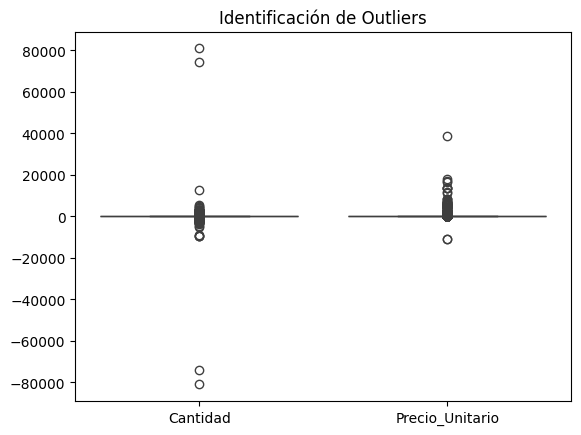

In [77]:
# Para el caso de las varaibles numéricas se identificarán las condiciones del dataset por medio de
#  estadísticas descriptivas como el valor mínimo, máximo, promedio y cuartiles. Así como la visualización de los
#  datos por medio de gráficos de dispersión

# Análisis con estadísticas descriptivas
print("---"*30)
print('Análisis descriptivo de las variables numéricas')
print("---"*30)

print(df.select_dtypes(include=['number']).describe())

# Análisis visual

sns.boxplot(data=df[['Cantidad','Precio_Unitario']])
plt.title('Identificación de Outliers')
plt.show()

Antes de eliminar los datos que presentan valores atípicos, se revisarán algunos de los datos que se encuentran por fuera de los valores esperados tanto para la vatiable cantidad como para la variable precio unitario. Para empezar, se revisarán los valores negativos, ya que son valores que, a primera vista, no presentan compatibilidad con el tipo de variable.

In [78]:
# Observando los resultados obtenidos, podemos decir que se deben de eliminar los registros donde se presenten
#  condiciones como:
#  1. Cantidades y precios unitarios negativos.

df[(df['Cantidad']<=-0)]

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


Como se puede observar en la anterior gráfica, se presentan casos donde los valores negativos hacen referencia a un descuento (Descripción: Discount) o a aparentes facturas realizadas de forma manual (Description: Manual). Así mismo, podemos evidenciar que la mayoría de los datos encontrados hacen relación a una posible cuenta de cobro, ya que el número de factura inicia con el indicativo "C". Con esto presente se continúa analizando las condiciones que presentan condiciones atípicas más severas, es decir con cantidades extremas, tanto negativas como positivas según el boxplot presentado.

In [79]:
df[(df['Cantidad']<=-2000) | (df['Cantidad']>=2000)].sort_values(by='Cantidad')

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom
225528,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,NaN,United Kingdom
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,0.00,NaN,United Kingdom
431381,573596,79323W,"Unsaleable, destroyed.",-4830,2011-10-31 15:17:00,0.00,NaN,United Kingdom
341601,566768,16045,NaN,-3667,2011-09-14 17:53:00,0.00,NaN,United Kingdom
323458,565304,16259,NaN,-3167,2011-09-02 12:18:00,0.00,NaN,United Kingdom


In [80]:
df[((df['Descripción']=='MEDIUM CERAMIC TOP STORAGE JAR') & ((df['Cantidad']>70000) | (df['Cantidad']<-70000)))]

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom


Como se puede observar, se pueden identificar casos especiales donde se tienen diferentes condiciones contables que se registraron dentro de las facturas. Si bien es una práctica propia de la empresa, se deben de mantener los registros de tal forma que se pueda contar con una trazabilidad de los casos especiales registrados por día. Sin embargo, entendiendo que mantener estos datos dentro de un mismo DataFrame puede generar errores a la hora de analizar el conjunto de datos completo. Se optó por separar estos ajustes de inventario en un DataFrame independiente que puede ser utilizado en otro tipo de análisis.

In [81]:
# 1. Identificamos grupos (Código + Cantidad Absoluta) 
# que sumados den 0 y tengan exactamente 2 registros (la entrada y la salida)
criterios = ['Cod_Inventario', 'Descripción', 'Precio_Unitario']
df['es_cancelacion'] = df.groupby(criterios)['Cantidad'].transform('sum') == 0

df[df['es_cancelacion']==True].sort_values(by='Cod_Inventario')

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País,es_cancelacion
390504,C570552,20712,JUMBO BAG WOODLAND ANIMALS,-200,2011-10-11 11:01:00,1.74,16029.0,United Kingdom,True
390496,570522,20712,JUMBO BAG WOODLAND ANIMALS,200,2011-10-11 10:46:00,1.74,16029.0,United Kingdom,True
259970,559793,21067,VINTAGE RED TEATIME MUG,23,2011-07-12 12:43:00,1.06,17949.0,United Kingdom,True
304342,C563570,21067,VINTAGE RED TEATIME MUG,-23,2011-08-17 14:51:00,1.06,17949.0,United Kingdom,True
255423,C559345,21439,BASKET OF TOADSTOOLS,-408,2011-07-07 17:16:00,1.06,13984.0,United Kingdom,True
...,...,...,...,...,...,...,...,...,...
361969,568398,POST,POSTAGE,1,2011-09-27 10:26:00,5.00,14543.0,United Kingdom,True
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,True
173277,C551685,POST,POSTAGE,-1,2011-05-03 12:51:00,8142.75,16029.0,United Kingdom,True
419666,572849,S,SAMPLES,1,2011-10-26 12:20:00,33.05,NaN,United Kingdom,True


Debido a que se identificaron condiciones donde se presentan condiciones especiales como muestras, costos de transporte y correo, con las condiciones inicialmente definidas, se debe de ajustar el código para que realice una separación adecuada de la información.

In [148]:
# 1. Extraemos solo los dígitos del código del inventario. 
#  Con este paso evitamos que se ingresen ajustes contables al registro de las cancelaciones.
#  r'\d+' busca secuencias de números. 'join' los une si están esparcidos.
df['solo_numeros'] = df['Cod_Inventario'].astype(str).str.findall(r'\d+').str.join('')

# 2. Identificamos si es un producto real o un ajuste
# Si 'solo_numeros' no está vacío, es un producto.
# También se tomarán los números que sean de más de dos dígitos,
#  con el fin de evitar que se ingresen ajustes con un consecutivo numérico
df['tipo_item'] = np.where(df['solo_numeros'] != '', 'Producto', 'Ajuste_Contable')
df['tipo_item'] = np.where(df['solo_numeros'].str.len() > 2, 'Producto', 'Ajuste_Contable')

# Separamos la información en DataFrames separados para análisis independientes.
# DataFrame sólo con movimientos de productos reales
df_productos = df[df['tipo_item'] == 'Producto'].copy()

# Por otro lado, se separan las cancelaciones
df_productos['Cantidad_Abs'] = df_productos['Cantidad'].abs()
criterios = ['Cod_Inventario','Descripción', 'Precio_Unitario', 'Cantidad_Abs'] 
df_productos['es_cancelacion'] = df_productos.groupby(criterios)['Cantidad'].transform('sum') == 0

df_anulados = df_productos[df_productos['es_cancelacion']==True].copy()
df_movimientos = df_productos[df_productos['es_cancelacion']==False].copy()

# DataFrame con los ajustes (lo que no tiene números)
df_ajustes_contables = df[df['tipo_item'] == 'Ajuste_Contable'].copy()

df_ajustes_contables

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País,es_cancelacion,solo_numeros,tipo_item
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France,False,,Ajuste_Contable
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,False,,Ajuste_Contable
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands,False,,Ajuste_Contable
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662.0,Germany,False,,Ajuste_Contable
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.00,14911.0,EIRE,False,2,Ajuste_Contable
...,...,...,...,...,...,...,...,...,...,...,...
541540,581498,DOT,DOTCOM POSTAGE,1,2011-12-09 10:26:00,1714.17,NaN,United Kingdom,False,,Ajuste_Contable
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,False,,Ajuste_Contable
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany,False,,Ajuste_Contable
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany,False,,Ajuste_Contable


Por otra parte, se puede observar que hay un ajuste creado para daños o averías, en este caso, se tomarán también en un DataFrame independiente con el fin de que pueda ser utilizado para otros análisis orientados a determinar qué productos se dañan más según el histórico disponible con el fin de implementar estrategias logísticas y cuantificar posibles pérdidas generadas por estos daños. Sin embargo, como las causales de daño se usaron en la descripción del inventario, se creará un registro maestro desde el cual se reemplazarán las descripciones que se tienen y se creará una columna adicional de observaciones para almacenar las condiciones que llevaron a identificar el daño.

In [127]:
df_movimientos[(df_movimientos['Cantidad']<0) | (df_movimientos['Cantidad']>10000)].sort_values(by='Cantidad')

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País,es_cancelacion,solo_numeros,tipo_item,Cantidad_Abs
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom,False,23005,Producto,9600
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom,False,23005,Producto,9600
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom,False,84347,Producto,9360
225528,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,NaN,United Kingdom,False,23003,Producto,9058
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,0.00,NaN,United Kingdom,False,72140,Producto,5368
...,...,...,...,...,...,...,...,...,...,...,...,...
540091,C581466,21232,STRAWBERRY CERAMIC TRINKET POT,-1,2011-12-08 19:20:00,1.25,13883.0,United Kingdom,False,21232,Producto,1
1985,C536548,20957,PORCELAIN HANGING BELL SMALL,-1,2010-12-01 14:33:00,1.45,12472.0,Germany,False,20957,Producto,1
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,False,84978,Producto,1
537496,C581305,22627,MINT KITCHEN SCALES,-1,2011-12-08 11:42:00,8.50,16933.0,United Kingdom,False,22627,Producto,1


In [163]:
# Definimos condiciones para identificar averías/daños
condicion_ajuste = (df_movimientos['Precio_Unitario'] == 0.0) & (df_movimientos['Cantidad'] < 0)

# Etiquetamos los registros
df_movimientos['Tipo_Registro'] = np.where(condicion_ajuste, 'Ajuste_Averia', 'Venta')

# DataFrame para análisis de ingresos (Ventas reales)
df_ventas = df_movimientos[df_movimientos['Tipo_Registro'] == 'Venta'].copy()

# DataFrame para análisis de mermas (Pérdidas de inventario)
df_perdidas = df_movimientos[df_movimientos['Tipo_Registro'] == 'Ajuste_Averia'].copy()

# Creamos un mapeo: tomamos el primer nombre no nulo para cada código
mapeo_nombres = df.dropna(subset=['Descripción']).drop_duplicates('Cod_Inventario').set_index('Cod_Inventario')['Descripción']

# Llenamos los vacíos o reemplazamos descripciones inconsistentes
df_perdidas['Observaciones'] = df_perdidas['Descripción']

df_perdidas['Descripción'] = df_perdidas['Cod_Inventario'].map(mapeo_nombres)

palabras_ruido = r'\?|check'

mask = (
    df_perdidas['Observaciones'].isna() | 
    df_perdidas['Observaciones'].str.contains(palabras_ruido, case=False, na=False)
)

df_revisar_perdidas = df_perdidas[mask].copy()
df_perdidas = df_perdidas[~mask]

df_revisar_perdidas.sort_values(by='Cantidad')

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País,es_cancelacion,solo_numeros,tipo_item,Cantidad_Abs,Tipo_Registro,Observaciones
341601,566768,16045,POPART WOODEN PENCILS ASST,-3667,2011-09-14 17:53:00,0.0,NaN,United Kingdom,False,16045,Producto,3667,Ajuste_Averia,NaN
323458,565304,16259,PIECE OF CAMO STATIONERY SET,-3167,2011-09-02 12:18:00,0.0,NaN,United Kingdom,False,16259,Producto,3167,Ajuste_Averia,NaN
113580,545990,84598,BOYS ALPHABET IRON ON PATCHES,-3000,2011-03-08 13:07:00,0.0,NaN,United Kingdom,False,84598,Producto,3000,Ajuste_Averia,check
270886,560600,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,-2834,2011-07-19 17:04:00,0.0,NaN,United Kingdom,False,18007,Producto,2834,Ajuste_Averia,NaN
323469,565310,21829,DINOSAUR KEYRINGS ASSORTED,-1897,2011-09-02 12:26:00,0.0,NaN,United Kingdom,False,21829,Producto,1897,Ajuste_Averia,?missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281592,561543,22202,MILK PAN PINK POLKADOT,-1,2011-07-28 10:10:00,0.0,NaN,United Kingdom,False,22202,Producto,1,Ajuste_Averia,NaN
280721,561487,22168,ORGANISER WOOD ANTIQUE WHITE,-1,2011-07-27 13:51:00,0.0,NaN,United Kingdom,False,22168,Producto,1,Ajuste_Averia,NaN
42498,539994,22830,UTILTY CABINET WITH HOOKS,-1,2011-01-04 10:09:00,0.0,NaN,United Kingdom,False,22830,Producto,1,Ajuste_Averia,NaN
42503,539999,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,-1,2011-01-04 10:16:00,0.0,NaN,United Kingdom,False,20892,Producto,1,Ajuste_Averia,NaN


In [164]:
df_perdidas

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País,es_cancelacion,solo_numeros,tipo_item,Cantidad_Abs,Tipo_Registro,Observaciones
13264,537432,35833G,4 GOLD FLOCK CHRISTMAS BALLS,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom,False,35833,Producto,43,Ajuste_Averia,damages
21338,538072,22423,REGENCY CAKESTAND 3 TIER,-13,2010-12-09 14:10:00,0.0,NaN,United Kingdom,False,22423,Producto,13,Ajuste_Averia,faulty
22296,538161,46000S,POLYESTER FILLER PAD 40x40cm,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom,False,46000,Producto,100,Ajuste_Averia,Dotcom sales
22297,538162,46000M,POLYESTER FILLER PAD 45x45cm,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom,False,46000,Producto,100,Ajuste_Averia,Dotcom sales
42564,540010,22501,PICNIC BASKET WICKER LARGE,-100,2011-01-04 11:13:00,0.0,NaN,United Kingdom,False,22501,Producto,100,Ajuste_Averia,reverse 21/5/10 adjustment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535329,581206,21693,SMALL HAMMERED SILVER CANDLEPOT,-87,2011-12-07 18:34:00,0.0,NaN,United Kingdom,False,21693,Producto,87,Ajuste_Averia,mixed up
535330,581207,21688,SILVER PLATE CANDLE BOWL SMALL,-337,2011-12-07 18:34:00,0.0,NaN,United Kingdom,False,21688,Producto,337,Ajuste_Averia,mixed up
535335,581212,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom,False,22578,Producto,1050,Ajuste_Averia,lost
536908,581226,23090,VINTAGE GLASS T-LIGHT HOLDER,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom,False,23090,Producto,338,Ajuste_Averia,missing


Con estos ajustes, se espera contar con un DataFrame de ventas más limpio y listo para procesar, por lo tanto, procedemos nuevamente a realizar la graficación de el boxplot con el fin de identificar si se redujeron significativamente los valores atípicos

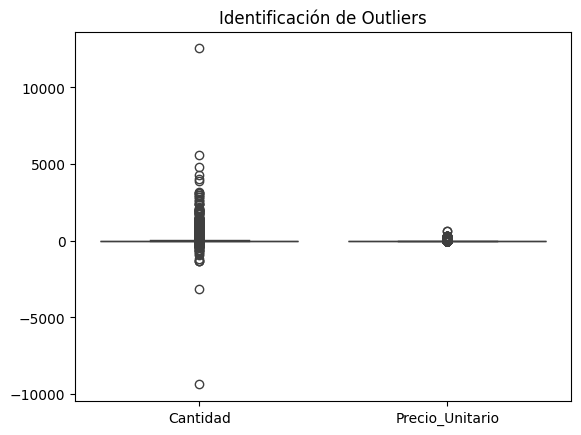

In [149]:
sns.boxplot(data=df_ventas[['Cantidad','Precio_Unitario']])
plt.title('Identificación de Outliers')
plt.show()


Como se puede observar en el boxplot anterior, aún después de realizar las limpiezas oportunas de los datos, siguen existiendo valores atípicos que pueden introducir ruido y conducir a errores al momento de ser tenidos en cuenta para el entrenamiento de modelos de aprendizaje automático. Por esta razón, y siguiendo la práctica de aislar estos datos en un DataFrame aparte para realizar un análisis independiente que permita definir si son errores de digitación o hacen referencia a otro tipo de situaciones del día a día de un negocio.

Ahora analizaremos la condición del precio unitario, ya que se sigue centrando en el 0, lo cual nos podría estar indicando errores en la información. Así mismo, entendiendo que se aislaron descuentos, muestras y daños de mercancía, no se deberían de presentar valores negativos en los productos que fueron clasificados como parte de ventas realmente realizadas.

In [ ]:
df_ventas[df_ventas['Precio_Unitario'] == 0.0]

,Nro_Factura,Cod_Inventario,Descripción,Cantidad,Fecha_factura,Precio_Unitario,ID_Cliente,País,es_cancelacion,solo_numeros,tipo_item,Cantidad_Abs,Tipo_Registro
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,False,22139,Producto,56,Venta
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,False,21134,Producto,1,Venta
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,False,22145,Producto,1,Venta
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,False,37509,Producto,1,Venta
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,False,85226,Producto,1,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,2011-12-07 18:36:00,0.0,NaN,United Kingdom,False,22142,Producto,14,Venta
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,False,72817,Producto,27,Venta
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,False,46000,Producto,240,Venta
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,False,46000,Producto,300,Venta


In [161]:
df_revisar_ventas = df_ventas[(df_ventas['Precio_Unitario'] == 0) & (df_ventas['Cantidad'] > 0)].copy()
df_ventas = df_ventas[~df_revisar_ventas]

df_revisar_ventas['Observaciones'] = df_revisar_ventas['Descripción']

df_revisar_ventas['Descripción'] = df_revisar_ventas['Cod_Inventario'].map(mapeo_nombres)

df_revisar_ventas


TypeError: bad operand type for unary ~: 'str'

Frecuencia de casos especiales:
  Letra  Frecuencia
0     M         571
1     D          77
2     S          63
3     B           3
4     m           1


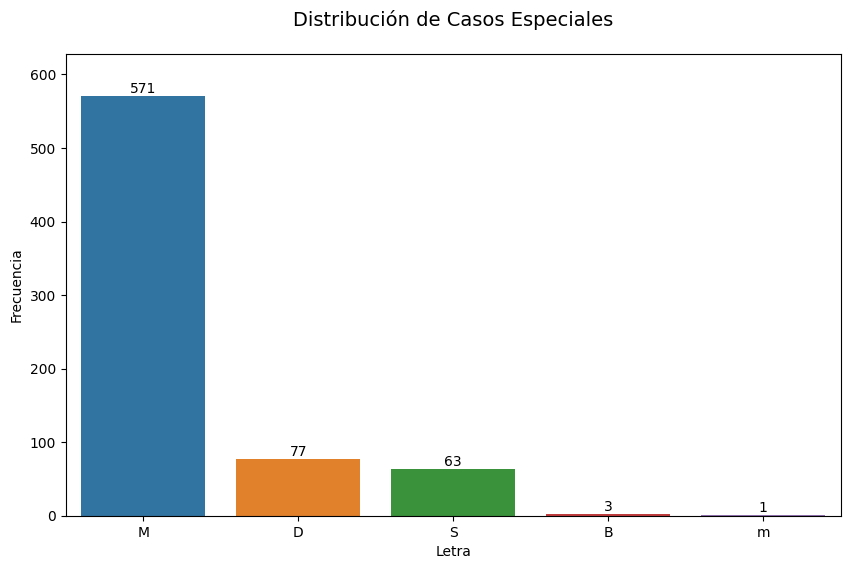

In [85]:
codigos = df[df['Cod_Inventario'].str.len() == 1]

codigos_especiales = codigos['Cod_Inventario'].str.strip().value_counts().reset_index()
codigos_especiales.columns = ['Letra', 'Frecuencia']

print("Frecuencia de casos especiales:")
print(codigos_especiales)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=codigos_especiales, x='Letra', y='Frecuencia', hue='Letra', legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribución de Casos Especiales', fontsize=14, pad=20)
plt.ylim(0, codigos_especiales['Frecuencia'].max() * 1.1)
plt.show()

In [86]:
# Agrupa por letra y junta las descripciones únicas en una lista
descripciones_por_letra = codigos.groupby('Cod_Inventario')['Descripción'].unique()

print(descripciones_por_letra)


Cod_Inventario
B    [Adjust bad debt]
D           [Discount]
M             [Manual]
S            [SAMPLES]
m             [Manual]
Name: Descripción, dtype: object


---
### Notas:
Hay clientes que no tienen Id, pueden ser ventas a minoristas, pero esto genera confusión para el análisis. Así mismo sucede con la descripción, hay valores NaN para códigos que tienen diferentes descripciones

Hay cantidades que hacen referencia a descuentos, pero hay unas demasiado alejadas.

Las facturas que inician con C parecen tratarse de ajustes por medio de cuentas de cobro